In [92]:
from glob import glob

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
from io import StringIO
tbl = StringIO('''
| Grid Location (#) | Wafer Center Coordinate (in) | Step Height (nm) | Fit Param. Error (nm) |
| ----------------- | ---------------------------- | ---------------- | --------------------- |
| 0                 | (-4, 4)                      | 34.5             | 0.1                   |
| 1                 | (0, 4)                       | 46.2             | 0.2                   |
| 2                 | (4, 4)                       | 29.4             | 0.5                   |
| 3                 | (-4, 0)                      | 47.2             | 0.3                   |
| 4                 | (0, 0)                       | 46.1             | 0.6                   |
| 5                 | (4, 0)                       | 47.9             | 0.4                   |
| 6                 | (-4, -4)                     | 39.5             | 0.3                   |
| 7                 | (0, -4)                      | 67.3             | 0.3                   |
| 8                 | (4, -4)                      | 51.2             | 0.3                   |
''')
data = pd.read_csv(tbl, sep='|', usecols=[1,2,3,4], skiprows=3, names=['number', 'loc', 'h', 'dh'])
data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
import ast
data['loc'] = [ast.literal_eval(data['loc'].iloc[i]) for i in range(len(data['loc']))]
data['x'] = [data['loc'].iloc[i][0] for i in range(len(data['loc']))]
data['y'] = [data['loc'].iloc[i][1] for i in range(len(data['loc']))]

In [124]:
data['loc'][0], data['x'], data['y']

((-4, 4),
 0   -4
 1    0
 2    4
 3   -4
 4    0
 5    4
 6   -4
 7    0
 8    4
 Name: x, dtype: int64,
 0    4
 1    4
 2    4
 3    0
 4    0
 5    0
 6   -4
 7   -4
 8   -4
 Name: y, dtype: int64)

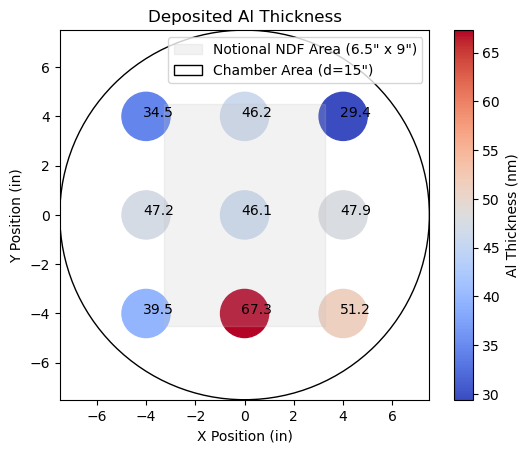

In [159]:
fig, ax = plt.subplots()
im = ax.scatter(data['x'], data['y'], s=1200, c=data['h'], cmap='coolwarm')
fig.colorbar(im, ax=ax, label='Al Thickness (nm)')
[ax.text(data['x'][i] + .5, data['y'][i], ha='center', s=f'{data["h"][i]:.1f}') for i in range(len(data['h']))]
ax.set_title('Deposited Al Thickness')
ax.set_xlabel('X Position (in)')
ax.set_ylabel('Y Position (in)')
w, h = 6.5, 9
rect = plt.Rectangle((-w/2, -h/2), w, h, edgecolor='silver', facecolor='silver', alpha=0.2, label='Notional NDF Area (6.5" x 9")')
ax.add_artist(rect)
circ = plt.Circle((0,0), 7.5, edgecolor='black', facecolor='none', label='Chamber Area (d=15")')
ax.set_aspect('equal')
ax.add_artist(circ)
ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-7.5, 7.5)
ax.legend()

In [163]:
data['h'].mean(), np.ptp(data['h']), data['h'].mean() / 190

(np.float64(45.47777777777778),
 np.float64(37.9),
 np.float64(0.23935672514619885))